# Driving log file explained
CSV file contains 7 columns.\
There are 3 cameras mounted on the car (center, left, right)\
\
Column 1: Path to image captured by center camera\
Column 2: Path to image captured by left camera\
Column 3: Path to image captured by right camera\
Column 4: Steering input (-1 to 1)\
Column 5: Throttle input (0-1)\
Column 6: Brake input (0 OR 1)\
Column 7: Speed in KM/h (max speed: 30.63811)

In [1]:
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


cols = ['center', 'left', 'right', 'steering', 'throttle', 'brake', 'speed']
raw_df = pd.read_csv('driving_log.csv', header=None, names=cols)

df = raw_df.select_dtypes(include=['number'])

df.info()
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6311 entries, 0 to 6310
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   steering  6311 non-null   float64
 1   throttle  6311 non-null   float64
 2   brake     6311 non-null   int64  
 3   speed     6311 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 197.3 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6311 entries, 0 to 6310
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   center    6311 non-null   object 
 1   left      6311 non-null   object 
 2   right     6311 non-null   object 
 3   steering  6311 non-null   float64
 4   throttle  6311 non-null   float64
 5   brake     6311 non-null   int64  
 6   speed     6311 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 345.3+ KB


# EDA

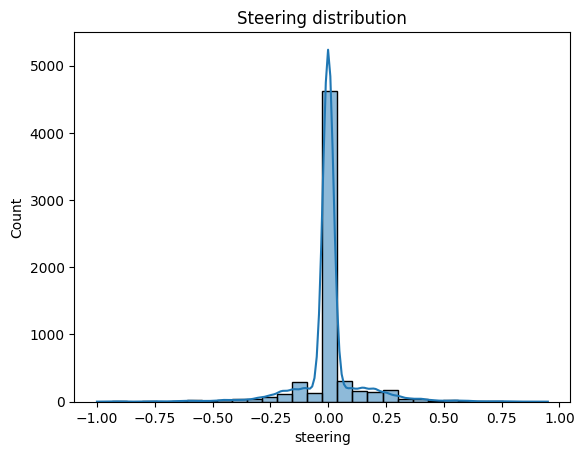

In [2]:
# steering only
sns.histplot(df["steering"], bins=30, kde=True)
plt.xlabel('steering')
plt.title('Steering distribution')
plt.show()

In [3]:
speed_max = df["speed"].max()
speed_max

np.float64(30.54485)

In [4]:
speed_min = df["speed"][df["speed"] > 4].min()
speed_min

np.float64(4.192685)

In [5]:
# Builds the bin edges from 0 up to just past max speed.
bins = range(0, int(df["speed"].max()) + 2)
counts = pd.cut(df["speed"], bins=bins, right=False).value_counts().sort_index()
counts


speed
[0, 1)        14
[1, 2)         3
[2, 3)         2
[3, 4)         2
[4, 5)         2
[5, 6)         3
[6, 7)         3
[7, 8)         2
[8, 9)         2
[9, 10)        3
[10, 11)       3
[11, 12)       3
[12, 13)       2
[13, 14)       3
[14, 15)       2
[15, 16)       3
[16, 17)       3
[17, 18)       3
[18, 19)       2
[19, 20)       3
[20, 21)       3
[21, 22)       3
[22, 23)       2
[23, 24)       3
[24, 25)       4
[25, 26)       3
[26, 27)       3
[27, 28)       3
[28, 29)       4
[29, 30)       3
[30, 31)    6217
Name: count, dtype: int64

In [6]:
# Builds the bin edges from 0 up to just past max speed.
steer_counts = (
    pd.cut(df["steering"], bins=20)
      .value_counts()
      .sort_index()
)
steer_counts

steering
(-1.002, -0.902]       3
(-0.902, -0.805]       5
(-0.805, -0.707]       7
(-0.707, -0.61]       10
(-0.61, -0.512]       19
(-0.512, -0.415]      30
(-0.415, -0.317]      42
(-0.317, -0.22]      116
(-0.22, -0.122]      261
(-0.122, -0.025]     279
(-0.025, 0.0725]    4777
(0.0725, 0.17]       307
(0.17, 0.268]        249
(0.268, 0.365]       101
(0.365, 0.463]        51
(0.463, 0.56]         24
(0.56, 0.658]         15
(0.658, 0.755]         9
(0.755, 0.853]         4
(0.853, 0.95]          2
Name: count, dtype: int64

In [7]:
s = df["steering"]

left  = s[s < 0]
right = s[s > 0]
straight = s[s == 0]  # or abs(s) < 0.05 if you want a deadzone

print("counts")
print("left:", len(left), f"({100*len(left)/len(s):.1f}%)")
print("right:", len(right), f"({100*len(right)/len(s):.1f}%)")
print("straight:", len(straight), f"({100*len(straight)/len(s):.1f}%)")

print("\nmagnitude (sum of |steering|)")
print("left effort:", left.abs().sum())
print("right effort:", right.abs().sum())

print("\naverage |steering| when turning")
print("left mean |steer|:", left.abs().mean())
print("right mean |steer|:", right.abs().mean())

counts
left: 772 (12.2%)
right: 920 (14.6%)
straight: 4619 (73.2%)

magnitude (sum of |steering|)
left effort: 158.200006
right effort: 188.2000057

average |steering| when turning
left mean |steer|: 0.20492228756476685
right mean |steer|: 0.2045652235869565


In [8]:
df.describe()

,steering,throttle,brake,speed
count,6311.000000,6311.000000,6311.0,6.311000e+03
mean,0.004754,0.998021,0.0,2.994525e+01
std,0.132358,0.041574,0.0,2.293737e+00
min,-1.000000,0.000000,0.0,4.721029e-07
25%,0.000000,1.000000,0.0,3.018768e+01
50%,0.000000,1.000000,0.0,3.019011e+01
75%,0.000000,1.000000,0.0,3.019030e+01
max,0.950000,1.000000,0.0,3.054485e+01


<Axes: xlabel='steering', ylabel='Count'>

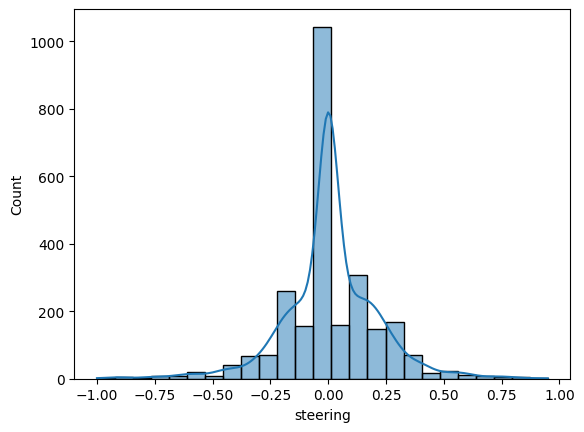

In [9]:
# keep only 10% of straight frames
straight = raw_df[(raw_df["steering"] == 0) & (raw_df["throttle"] == 1)].sample(frac=0.2, random_state=42)
turns = raw_df[raw_df["steering"] != 0]
balanced = pd.concat([straight, turns]).sample(frac=1, random_state=42)
sns.histplot(balanced["steering"], bins=25, kde=True)

In [10]:
df.describe()

,steering,throttle,brake,speed
count,6311.000000,6311.000000,6311.0,6.311000e+03
mean,0.004754,0.998021,0.0,2.994525e+01
std,0.132358,0.041574,0.0,2.293737e+00
min,-1.000000,0.000000,0.0,4.721029e-07
25%,0.000000,1.000000,0.0,3.018768e+01
50%,0.000000,1.000000,0.0,3.019011e+01
75%,0.000000,1.000000,0.0,3.019030e+01
max,0.950000,1.000000,0.0,3.054485e+01


In [11]:
balanced.describe()

,steering,throttle,brake,speed
count,2612.000000,2612.0,2612.0,2612.000000
mean,0.011485,1.0,0.0,30.003955
std,0.205572,0.0,0.0,1.685629
min,-1.000000,1.0,0.0,5.121005
25%,-0.050000,1.0,0.0,30.180350
50%,0.000000,1.0,0.0,30.188120
75%,0.100000,1.0,0.0,30.190180
max,0.950000,1.0,0.0,30.466760


In [12]:
s = balanced["steering"]

left  = s[s < 0]
right = s[s > 0]
straight = s[s == 0]  # or abs(s) < 0.05 if you want a deadzone

print("counts")
print("left:", len(left), f"({100*len(left)/len(s):.1f}%)")
print("right:", len(right), f"({100*len(right)/len(s):.1f}%)")
print("straight:", len(straight), f"({100*len(straight)/len(s):.1f}%)")

print("\nmagnitude (sum of |steering|)")
print("left effort:", left.abs().sum())
print("right effort:", right.abs().sum())

print("\naverage |steering| when turning")
print("left mean |steer|:", left.abs().mean())
print("right mean |steer|:", right.abs().mean())

counts
left: 772 (29.6%)
right: 920 (35.2%)
straight: 920 (35.2%)

magnitude (sum of |steering|)
left effort: 158.200006
right effort: 188.2000057

average |steering| when turning
left mean |steer|: 0.20492228756476685
right mean |steer|: 0.2045652235869565


In [14]:
balanced

,center,left,right,steering,throttle,brake,speed
161,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.05,1.0,0,30.19068
1604,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.00,1.0,0,30.19069
6077,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.00,1.0,0,30.19027
3323,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.05,1.0,0,30.18975
5088,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.10,1.0,0,30.18807
...,...,...,...,...,...,...,...
2623,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.85,1.0,0,30.10747
670,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.15,1.0,0,30.18419
906,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.05,1.0,0,30.18972
1418,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.10,1.0,0,30.18936


In [13]:
balanced.to_csv("balanced_log.csv", index=False)